<a href="https://colab.research.google.com/github/alyona-vishnoi/learning-RL/blob/main/CQL_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
import random
from collections import deque
import matplotlib.pyplot as plt
import pickle
import gymnasium as gym

In [2]:
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/cartpole_offline_data.pkl', 'rb') as f:
    offline_data = pickle.load(f)

print(f"loaded {len(offline_data)} transitions")
print(f"first row: {offline_data[0]}")

Mounted at /content/drive
loaded 50000 transitions
first row: (array([0.00818179, 0.04240355, 0.00976949, 0.01986618], dtype=float32), 1, 1.0, array([ 0.00902986,  0.23738404,  0.01016681, -0.2697184 ], dtype=float32), False, 0.975)


(state, action, reward, next_state, done, propensity)

In [3]:
# DQN network
class DQN(nn.Module):
    def __init__(self, in_states, h1_nodes, out_actions):
        super().__init__()
        self.fc1 = nn.Linear(in_states, h1_nodes)
        self.out = nn.Linear(h1_nodes, out_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.out(x)
        return x


# ReplayMemory + load_dataset
class ReplayMemory():
    def __init__(self, maxlen):
        self.memory = deque([], maxlen=maxlen)

    def append(self, transition):
        self.memory.append(transition)

    def load_dataset(self, data):
        for transition in data:
            self.memory.append(transition)
        print(f"buffer loaded: {len(self.memory)} transitions")

    def sample(self, sample_size):
        return random.sample(self.memory, sample_size)

    def __len__(self):
        return len(self.memory)

In DQN the buffer grows during training as the agent collects new experience. In CQL the buffer is loaded once before training starts and never touched again. No env.step(), no store_transition(), nothing added during the training loop. The buffer is frozen from the start.

# Load the data into the buffer and verify:

In [4]:
state_dim  = 4
action_dim = 2

buffer = ReplayMemory(maxlen=100000)
buffer.load_dataset(offline_data)

print(f"buffer size: {len(buffer)}")

# sanity check — sample one batch and inspect shapes
batch = buffer.sample(64)
states, actions, rewards, next_states, dones, propensities = zip(*batch)

states      = torch.tensor(np.array(states),      dtype=torch.float32)
actions     = torch.tensor(actions,                dtype=torch.int64).unsqueeze(1)
rewards     = torch.tensor(rewards,                dtype=torch.float32)
next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
dones       = torch.tensor(dones,                  dtype=torch.float32)
propensities = torch.tensor(propensities,          dtype=torch.float32)

print(f"states shape:       {states.shape}")
print(f"actions shape:      {actions.shape}")
print(f"rewards shape:      {rewards.shape}")
print(f"next_states shape:  {next_states.shape}")
print(f"dones shape:        {dones.shape}")
print(f"propensities shape: {propensities.shape}")

buffer loaded: 50000 transitions
buffer size: 50000
states shape:       torch.Size([64, 4])
actions shape:      torch.Size([64, 1])
rewards shape:      torch.Size([64])
next_states shape:  torch.Size([64, 4])
dones shape:        torch.Size([64])
propensities shape: torch.Size([64])


# Vanilla DQN on offline data (no CQL penalty)
*goal: show overestimation problem before fixing it*

In [5]:
class DQNOffline:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 batch_size=64, sync_freq=500):
        self.action_dim  = action_dim
        self.gamma       = gamma
        self.batch_size  = batch_size
        self.sync_freq   = sync_freq
        self.step_count  = 0

        self.policy_net  = DQN(state_dim, 128, action_dim)
        self.target_net  = DQN(state_dim, 128, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer   = torch.optim.Adam(self.policy_net.parameters(), lr=lr)

    def train_step(self, buffer):
        batch = buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones, _ = zip(*batch)

        states      = torch.tensor(np.array(states),      dtype=torch.float32)
        actions     = torch.tensor(actions,                dtype=torch.int64).unsqueeze(1)
        rewards     = torch.tensor(rewards,                dtype=torch.float32)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
        dones       = torch.tensor(dones,                  dtype=torch.float32)

        current_q   = self.policy_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q   = rewards + self.gamma * max_next_q * (1 - dones)

        loss = F.mse_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.sync_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item(), current_q.mean().item()

No epsilon, no select_action, no store_transition — all removed because there's no environment interaction. The train_step takes buffer as an argument instead of using self.buffer because the buffer is shared and pre-loaded. And it returns loss and current_q.mean() — we want to track Q values to see the overestimation.

In [9]:
# vanilla DQN training on offline data

dqn_offline = DQNOffline(state_dim, action_dim)

n_steps     = 50000
dqn_losses  = []
dqn_q_vals  = []

for step in range(n_steps):
    loss, mean_q = dqn_offline.train_step(buffer)
    dqn_losses.append(loss)
    dqn_q_vals.append(mean_q)

    if (step + 1) % 1000 == 0:
        print(f"step {step+1:5d} | loss: {loss:.4f} | mean Q: {mean_q:.4f}")

print("done")

step  1000 | loss: 0.0001 | mean Q: 2.0934
step  2000 | loss: 0.0006 | mean Q: 4.1291
step  3000 | loss: 0.0013 | mean Q: 6.1689
step  4000 | loss: 0.0005 | mean Q: 8.2768
step  5000 | loss: 0.0016 | mean Q: 10.5655
step  6000 | loss: 0.0039 | mean Q: 12.9537
step  7000 | loss: 0.0046 | mean Q: 15.5659
step  8000 | loss: 0.0065 | mean Q: 18.6800
step  9000 | loss: 0.0131 | mean Q: 21.7875
step 10000 | loss: 0.0088 | mean Q: 25.0358
step 11000 | loss: 0.0321 | mean Q: 28.5315
step 12000 | loss: 0.0268 | mean Q: 32.1153
step 13000 | loss: 37.1968 | mean Q: 36.6277
step 14000 | loss: 0.0360 | mean Q: 42.5278
step 15000 | loss: 0.1795 | mean Q: 50.2317
step 16000 | loss: 0.1377 | mean Q: 60.9612
step 17000 | loss: 0.1591 | mean Q: 74.4314
step 18000 | loss: 0.0704 | mean Q: 85.4218
step 19000 | loss: 0.0673 | mean Q: 97.9545
step 20000 | loss: 0.1390 | mean Q: 111.8598
step 21000 | loss: 229.8107 | mean Q: 125.3359
step 22000 | loss: 0.2625 | mean Q: 137.9290
step 23000 | loss: 0.8483 | me

Q value keeps climbing, and blows past true value (theorectical max if agent playes forever is 100 - with gamma = 0.99 so  1 / (1 - 0.99) = 100 by infinite geometic series)

The loss is exploding because Q values are so inflated that Bellman targets become enormous numbers, which cause huge gradient updates, which inflate Q values further. It's a runaway feedback loop.

# CQLAgent class

In [7]:
class CQLAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 batch_size=64, sync_freq=500, alpha=1.0):
        self.action_dim  = action_dim
        self.gamma       = gamma
        self.batch_size  = batch_size
        self.sync_freq   = sync_freq
        self.alpha       = alpha      # CQL penalty weight
        self.step_count  = 0

        self.policy_net  = DQN(state_dim, 128, action_dim)
        self.target_net  = DQN(state_dim, 128, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer   = torch.optim.Adam(self.policy_net.parameters(), lr=lr)

    def train_step(self, buffer):
        batch = buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones, _ = zip(*batch)

        states       = torch.tensor(np.array(states),      dtype=torch.float32)
        actions      = torch.tensor(actions,               dtype=torch.int64).unsqueeze(1)
        rewards      = torch.tensor(rewards,               dtype=torch.float32)
        next_states  = torch.tensor(np.array(next_states), dtype=torch.float32)
        dones        = torch.tensor(dones,                 dtype=torch.float32)

        current_q    = self.policy_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q   = rewards + self.gamma * max_next_q * (1 - dones)

        bellman_loss = F.mse_loss(current_q, target_q)

        # CQL penalty

        # forward pass gives all Q values for all actions
        q_all_actions = self.policy_net(states) # (64, 2)

        # soft max over all actions (dim 1)
        logsumexp     = torch.logsumexp(q_all_actions, dim=1).mean()

        # Q value for the action actually in the data (the logged action)
        q_data        = q_all_actions.gather(1, actions).squeeze(1)

        # push down all, push up data actions
        cql_penalty   = logsumexp - q_data.mean()

        loss = bellman_loss + self.alpha * cql_penalty

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.sync_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return bellman_loss.item(), cql_penalty.item(), current_q.mean().item()

    def sync_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# CQL training loop

In [10]:
cql_agent = CQLAgent(state_dim, action_dim, alpha=1.0)

n_steps        = 50000
cql_bellman    = []
cql_penalties  = []
cql_q_vals     = []

for step in range(n_steps):
    bellman_loss, cql_penalty, mean_q = cql_agent.train_step(buffer)
    cql_bellman.append(bellman_loss)
    cql_penalties.append(cql_penalty)
    cql_q_vals.append(mean_q)

    if (step + 1) % 1000 == 0:
        print(f"step {step+1:5d} | bellman: {bellman_loss:.4f} | cql penalty: {cql_penalty:.4f} | mean Q: {mean_q:.4f}")

print("done")

step  1000 | bellman: 0.0559 | cql penalty: 0.5229 | mean Q: 2.1880
step  2000 | bellman: 0.0687 | cql penalty: 0.4973 | mean Q: 4.1805
step  3000 | bellman: 0.0996 | cql penalty: 0.4835 | mean Q: 6.1344
step  4000 | bellman: 0.1182 | cql penalty: 0.4650 | mean Q: 8.0343
step  5000 | bellman: 0.2210 | cql penalty: 0.4587 | mean Q: 9.9955
step  6000 | bellman: 0.0332 | cql penalty: 0.4452 | mean Q: 11.8852
step  7000 | bellman: 0.0696 | cql penalty: 0.4071 | mean Q: 13.7281
step  8000 | bellman: 0.0550 | cql penalty: 0.3678 | mean Q: 15.5415
step  9000 | bellman: 0.0575 | cql penalty: 0.3945 | mean Q: 17.0854
step 10000 | bellman: 0.0866 | cql penalty: 0.3898 | mean Q: 18.7432
step 11000 | bellman: 5.8040 | cql penalty: 0.3883 | mean Q: 20.3341
step 12000 | bellman: 0.1317 | cql penalty: 0.4237 | mean Q: 21.8114
step 13000 | bellman: 0.1009 | cql penalty: 0.3877 | mean Q: 23.1771
step 14000 | bellman: 0.3060 | cql penalty: 0.4556 | mean Q: 24.6323
step 15000 | bellman: 0.1048 | cql pena

The rate of climb dropped dramatically. From steps 1-35k it was climbing about 1.4 per 1000 steps. From steps 45-50k it's climbing about 0.4 per 1000 steps. It's converging — looks like it'll plateau somewhere around 65-70, which is in the conservative-but-reasonable range below the theoretical 100. CQL is doing exactly what it should: underestimating deliberately rather than overestimating.

The penalty is also shrinking over time which means that the gap between logsumexp and q_data is closing. The network is learning to give data actions higher Q values relative to all actions, which is exactly the conservative property CQL aims for.

# Comparison plot


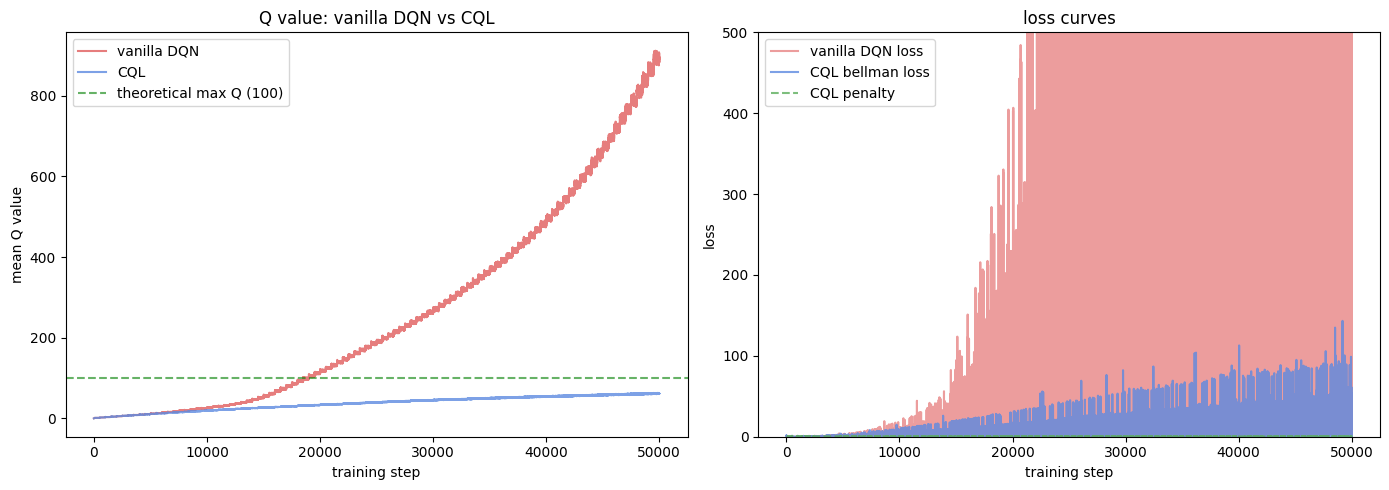

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q value comparison
axes[0].plot(dqn_q_vals,  label='vanilla DQN', alpha=0.8, color='#E05C5C')
axes[0].plot(cql_q_vals,   label='CQL',         alpha=0.8, color='#5C8AE0')
axes[0].axhline(100, color='green', linestyle='--', alpha=0.6, label='theoretical max Q (100)')
axes[0].set_xlabel('training step')
axes[0].set_ylabel('mean Q value')
axes[0].set_title('Q value: vanilla DQN vs CQL')
axes[0].legend()

# loss comparison
axes[1].plot(dqn_losses, label='vanilla DQN loss', alpha=0.6, color='#E05C5C')
axes[1].plot(cql_bellman, label='CQL bellman loss', alpha=0.8, color='#5C8AE0')
axes[1].plot(cql_penalties, label='CQL penalty',    alpha=0.8, color='#5CAE5C', linestyle='--')
axes[1].set_xlabel('training step')
axes[1].set_ylabel('loss')
axes[1].set_title('loss curves')
axes[1].set_ylim(0, 500)   # cap y axis so CQL is visible
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluating CQL model with DR OPE

In [13]:
from sklearn.linear_model import LinearRegression
import torch.nn.functional as F

# Train the reward model

In [14]:
X = np.array([
    np.append(row[0], row[1])   # state (4,) + action (1,) = (5,)
    for row in offline_data
])
y = np.array([row[2] for row in offline_data])   # rewards

reward_model = LinearRegression()
reward_model.fit(X, y)
print(f"reward model trained on {len(X)} rows")

reward model trained on 50000 rows


# Eval policy from CQL network

In [15]:
def cql_eval_policy(state):
    state_t  = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_vals = cql_agent.policy_net(state_t).squeeze(0)
    probs    = F.softmax(q_vals, dim=0).numpy()
    return {0: float(probs[0]), 1: float(probs[1])}

# DR estimator

In [16]:
def doubly_robust(data, eval_policy_fn, model):
    dr_values = []

    for row in data:
        state, action, reward, next_state, done, propensity = row

        probs      = eval_policy_fn(state)
        pi_e       = probs[action]
        w          = pi_e / propensity

        # dm_component — expected reward under eval policy from this state
        dm_component = 0
        for a, prob in probs.items():
            x             = np.append(state, a).reshape(1, -1)
            dm_component += prob * model.predict(x)[0]

        # model prediction for the action actually taken
        actual_pred  = model.predict(np.append(state, action).reshape(1, -1))[0]

        # IPS correction for model error
        correction   = w * (reward - actual_pred)

        dr_values.append(dm_component + correction)

    return np.mean(dr_values)

dr_estimate = doubly_robust(offline_data, cql_eval_policy, reward_model)
print(f"\nDR estimate of CQL policy value: {dr_estimate:.4f}")


DR estimate of CQL policy value: 1.0000


# True value by running CQL greedily

In [17]:
def true_cql_value(agent, n_episodes=100):
    env          = gym.make('CartPole-v1')
    total_reward = 0

    for _ in range(n_episodes):
        state, info      = env.reset()
        terminated       = truncated = False
        episode_reward   = 0

        while not (terminated or truncated):
            state_t  = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                action = cql_agent.policy_net(state_t).argmax().item()
            state, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward

        total_reward += episode_reward

    env.close()
    return total_reward / n_episodes

true_value = true_cql_value(cql_agent)
print(f"true CQL policy value (avg episode reward): {true_value:.2f}")

true CQL policy value (avg episode reward): 500.00


# comparison

In [18]:
print(f"\n{'='*45}")
print(f"DR estimate:   {dr_estimate:.4f}")
print(f"true value:    {true_value:.4f}")
print(f"error:         {abs(dr_estimate - true_value):.4f}")
print(f"{'='*45}")


DR estimate:   1.0000
true value:    500.0000
error:         499.0000


In [19]:
test_inputs = np.array([np.append(row[0], row[1]) for row in offline_data[:5]])
print(reward_model.predict(test_inputs))
print(f"reward model intercept: {reward_model.intercept_:.4f}")
print(f"reward model coefs: {reward_model.coef_}")

[1. 1. 1. 1. 1.]
reward model intercept: 1.0000
reward model coefs: [0. 0. 0. 0. 0.]


All rewards in in offline data are exactly 1.0 — CartPole gives +1 every step, no variation at all. So LinearRegression reward model learned one thing: predict 1.0 for every (state, action) pair regardless of input.

CartPole's reward is always 1.0 regardless of state or action, so the reward model is useless here.

DR is only as good as the variation in your reward signal. When rewards are constant, OPE can't distinguish between a good policy and a bad one

The fix — use episodic return instead of per-step reward

Instead of storing reward=1.0 per step, we can store the discounted return from that step onward as the reward signal. That captures how long the episode lasted from each state.

In [20]:
# reprocess offline data with discounted returns

gamma = 0.99

def compute_returns(data, gamma):
    processed = []

    # find episode boundaries
    episode_start = 0
    episodes = []
    current_episode = []

    for row in data:
        state, action, reward, next_state, done, propensity = row
        current_episode.append(row)
        if done:
            episodes.append(current_episode)
            current_episode = []

    # for incomplete last episode
    if current_episode:
        episodes.append(current_episode)

    # compute discounted return for each step
    for episode in episodes:
        T = len(episode)
        for t, row in enumerate(episode):
            state, action, reward, next_state, done, propensity = row
            # G_t = sum of gamma^k * reward from step t onward
            G = sum(gamma**k * episode[t+k][2] for k in range(T-t))
            processed.append((state, action, G, next_state, done, propensity))

    return processed

offline_data_returns = compute_returns(offline_data, gamma)

# check — returns should now vary
returns = [row[2] for row in offline_data_returns]
print(f"min return:  {min(returns):.4f}")
print(f"max return:  {max(returns):.4f}")
print(f"mean return: {np.mean(returns):.4f}")
print(f"std return:  {np.std(returns):.4f}")

min return:  1.0000
max return:  99.3430
mean return: 80.3301
std return:  24.4556


In [21]:
# retrain reward model on returns and rerun DR
X_returns = np.array([
    np.append(row[0], row[1])
    for row in offline_data_returns
])
y_returns = np.array([row[2] for row in offline_data_returns])

reward_model_returns = LinearRegression()
reward_model_returns.fit(X_returns, y_returns)
print(f"reward model retrained")
print(f"sample predictions: {reward_model_returns.predict(X_returns[:5]).round(2)}")
print(f"actual returns:     {y_returns[:5].round(2)}")



dr_estimate_returns = doubly_robust(
    offline_data_returns,
    cql_eval_policy,
    reward_model_returns
)

print(f"\nDR estimate (with returns): {dr_estimate_returns:.4f}")
print(f"true value:                 {true_value:.4f}")
print(f"error:                      {abs(dr_estimate_returns - true_value):.4f}")

reward model retrained
sample predictions: [61.83 62.67 63.99 64.33 64.72]
actual returns:     [99.34 99.34 99.33 99.32 99.32]

DR estimate (with returns): 79.4480
true value:                 500.0000
error:                      420.5520


In [25]:
T     = 500
gamma = 0.99
discounted_true = (1 - gamma**T) / (1 - gamma)

print("=" * 50)
print("PHASE 4 RESULTS SUMMARY")
print("=" * 50)

print(f"\noverestimation problem:")
print(f"  vanilla DQN mean Q at 50k steps: {dqn_q_vals[-1]:.2f}")
print(f"  CQL mean Q at 50k steps:         {cql_q_vals[-1]:.2f}")
print(f"  theoretical max Q:               100.00")

print(f"\noffline policy evaluation (DR):")
print(f"  DR estimate (per-step return):   {dr_estimate_returns:.4f}")
print(f"  mean return in data:             {np.mean(returns):.4f}")
print(f"  DR error vs data mean:           {abs(dr_estimate_returns - np.mean(returns)):.4f}")

print(f"\nCQL policy quality:")
print(f"  avg episode reward (greedy):     {true_value:.2f}")
print(f"  discounted episode return:       {discounted_true:.2f}")
print(f"  DR estimate (discounted):        {dr_estimate_returns:.4f}")
print(f"  DR error vs discounted true:     {abs(dr_estimate_returns - discounted_true):.4f}")

print("=" * 50)

PHASE 4 RESULTS SUMMARY

overestimation problem:
  vanilla DQN mean Q at 50k steps: 885.12
  CQL mean Q at 50k steps:         61.63
  theoretical max Q:               100.00

offline policy evaluation (DR):
  DR estimate (per-step return):   79.4480
  mean return in data:             80.3301
  DR error vs data mean:           0.8821

CQL policy quality:
  avg episode reward (greedy):     500.00
  discounted episode return:       99.34
  DR estimate (discounted):        79.4480
  DR error vs discounted true:     19.8950


In [26]:
torch.save(cql_agent.policy_net.state_dict(),
           '/content/drive/MyDrive/cql_policy.pt')